In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [13]:
data = pd.read_csv("data.csv")
print("Original shape:", data.shape)

Original shape: (569, 33)


In [14]:
drop_cols = [c for c in ["id", "Unnamed: 32"] if c in data.columns]
if drop_cols:
    data = data.drop(columns=drop_cols)

In [15]:
y = data["diagnosis"] if "diagnosis" in data.columns else None

In [16]:
X = data.drop(columns=["diagnosis"]) if "diagnosis" in data.columns else data.copy()


In [17]:
X = X.apply(pd.to_numeric, errors="coerce")

In [18]:
X = X.replace([np.inf, -np.inf], np.nan)

In [19]:
X = X.fillna(X.median(numeric_only=True))

In [20]:
print("After cleaning -> Any NaN?", X.isna().any().any())
print("After cleaning -> Any Inf?", np.isinf(X.to_numpy()).any())
print("Cleaned shape:", X.shape)

After cleaning -> Any NaN? False
After cleaning -> Any Inf? False
Cleaned shape: (569, 30)


In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

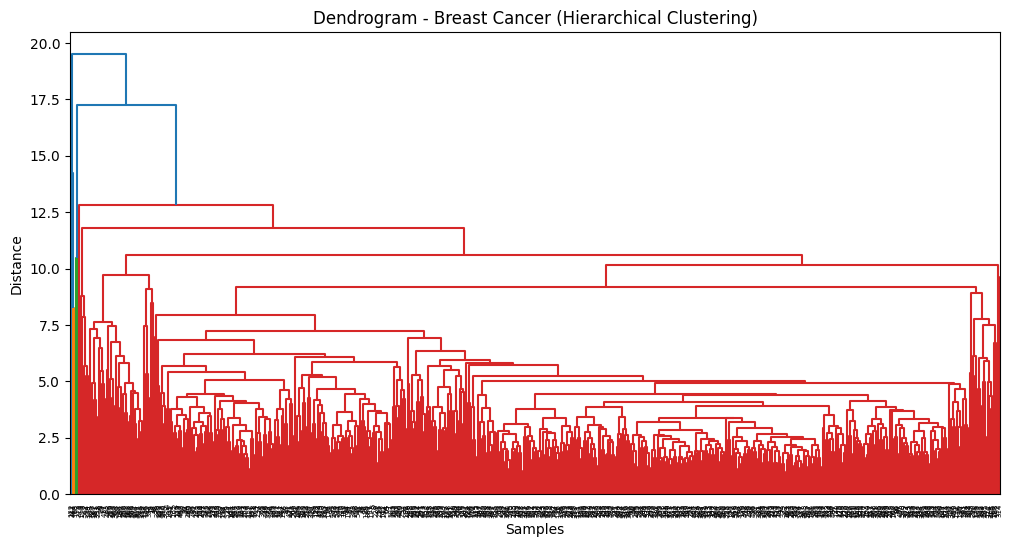

In [23]:
linked = linkage(X_scaled, method="average")

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Dendrogram - Breast Cancer (Hierarchical Clustering)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [24]:
model = AgglomerativeClustering(n_clusters=2, linkage="average")
labels = model.fit_predict(X_scaled)


In [25]:
result = data.copy()
result["Cluster"] = labels

In [26]:
print("\nCluster counts:")
print(result["Cluster"].value_counts())



Cluster counts:
Cluster
0    566
1      3
Name: count, dtype: int64


In [27]:
result.to_csv("breast_cancer_clustered.csv", index=False)
print("\nSaved: breast_cancer_clustered.csv")


Saved: breast_cancer_clustered.csv
